# Penalty sensitivity analysis

## Imports and paths

In [1]:
import pandas as pd
from matplotlib import pyplot as plt
import os
import sys
import numpy as np

In [2]:
current_path = os.getcwd()
cwd = os.path.dirname(current_path)
sys.path.append(os.path.join(cwd, "utilities"))

# Import pickle operations

from pickle_file_operations import read_pickle, write_pickle
from optimization_dataclasses import Optimization_Results
# pd.set_option('display.float_format', '{:.4f}'.format)

In [3]:
def saturation_func(df):
    x = df["flexibility_MWh"]
    y = df["updated_max_flexibility_MWh"]
    a = df["shaping_parameters"][0]
    b = df["shaping_parameters"][1]

    x_new = max(0.098, x)
    y_new = max(0.10, y)
    if y_new / x_new > 1:
        z = (-1 * b) ** -1 * x_new * ((np.log((y_new / x_new) - 1)) - a)
    else:
        x_new = 0.99 * y_new
        z = (-1 * b) ** -1 * x_new * ((np.log((y_new / x_new) - 1)) - a)
        
    z_positive = max(z, 0)
    return round(z_positive, 3)

In [4]:
def calculate_revenue(optimization_results: Optimization_Results): 

    df = optimization_results.decision_variables
    df["actual_flexibility_cost_DKK"] = df.apply(saturation_func, axis=1)
    df["net_revenue"] = df.market_price * df.flexibility_MWh - df.actual_flexibility_cost_DKK
    df["square_error"] = (df.actual_flexibility_cost_DKK - df.flexibility_cost_DKK)** 2
    return df

def results_summary(optimization_results: Optimization_Results): 

    df = optimization_results.decision_variables
    solve_check = 100 * round(optimization_results.mip_gap, 3) <= 1.0
    
    summary_dict = {"objective_value": df.net_revenue.sum(), 
                    "mean_square_error": df.square_error.mean(),
                    "runtime": optimization_results.runtime, 
                    "cpu_time": optimization_results.cpu_time, 
                    "mip_gap": 100 * round(optimization_results.mip_gap, 3), 
                    "solve_check": solve_check}
    return pd.DataFrame(summary_dict, index=[0])

def identify_best_case(df: pd.DataFrame):

    max_objective_value = df['objective_value'].max()
    
    # Step 2: Filter rows with the maximum objective value
    best_objective_cases = df[df['objective_value'] == max_objective_value]
    
    # Step 3: Among the filtered rows, find the row with the minimum solve time
    min_runtime = best_objective_cases['runtime'].min()
    best_case = best_objective_cases.loc[best_objective_cases['runtime'].idxmin()]
    return best_case

In [5]:
results_path = os.path.join(cwd, "penalty sensitivity results")
folders = ["PCTAR", "PCAR"]
summary_cols = ["objective_value", "mean_square_error", "runtime", "cpu_time", 
                "mip_gap", "solve_check", "methodology", "scenario_type", "case", "weights", "alpha"]

In [6]:
%%time
summary_tables = pd.DataFrame(columns = summary_cols)
for folder in folders:
    filepath = os.path.join(results_path, folder)
    for filename in list(os.listdir(filepath))[0: 1]:
        file_path = os.path.join(filepath, filename)
        data = read_pickle(file_path)
        for scenario, scenario_results in list(data.items()):
            for case, results in list(scenario_results.items()):
                for weights, alphas_result in list(results.items()):
                    for alpha, result_object in list(alphas_result.items()):
                        if alpha == 1:
                            result_object.decision_variables = calculate_revenue(result_object)
                            result_row = results_summary(result_object)
                            result_row[summary_cols[-5:-2]] = [folder, scenario, case]
                            result_row["weights"] = [weights] 
                            result_row["alpha"] = alpha
                            summary_tables.loc[len(summary_tables)] = result_row.values[0]
        write_pickle(data, os.path.join(filepath, "Results_with_revenue.pickle"))

CPU times: total: 2.16 s
Wall time: 4.94 s


In [7]:
best_cases = []
for key, df in list(summary_tables.groupby(["methodology", "scenario_type", "case"])):
    df['runtime'] = df['runtime'].astype(float)
    best_case = identify_best_case(df)
    best_cases.append(best_case)

In [8]:
best_cases_df = pd.concat(best_cases, axis = 1).transpose().reset_index(drop=True)

In [9]:
best_cases_df[best_cases_df.scenario_type == "Med_prices"].weights.value_counts()

weights
(2, -1)      10
(10, -1)      4
(1, 0)        3
(1000, 0)     2
(5, -1)       1
Name: count, dtype: int64

In [10]:
write_pickle(best_cases_df, "best_cases_df.pickle")

In [11]:
mean_cols = summary_cols[0: 4]

In [12]:
best_cases_df.groupby(["scenario_type", "methodology"])[mean_cols].mean()

objective_value mean_square_error runtime cpu_time
scenario_type methodology                                                   
High_prices   PCAR           50861.258041       7970.344012  0.0264    0.042
              PCTAR          50861.258041       7970.344012   0.044   0.0593
Low_prices    PCAR            -514.241216       7441.737348  0.0477   0.0638
              PCTAR           -514.241216       7441.737348  0.0652   0.0796
Med_prices    PCAR            3870.432554       1695.128768  0.0305   0.0437
              PCTAR           3870.432554       1695.128768   0.044   0.0515

In [13]:
def get_penalty_value(weights):
    a, b = weights
    if b == 0:
        return str(a)
    elif b == 1:
        return r"${}^{{l}}$".format(a)
    else:
        return r"${}^{{-l}}$".format(a)
        

In [14]:
import colorsys

In [15]:
import colorsys

# Number of points
n_points = 9

# Generate unique colors in HSL space
colors = [colorsys.hls_to_rgb(i / n_points, 0.4, 1.0) for i in range(n_points)]

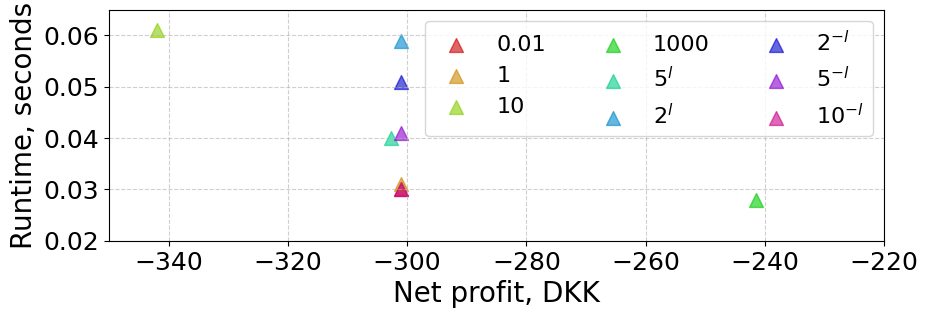

In [16]:
best_cases = []
for key, df in list(summary_tables.groupby(["methodology", "scenario_type", "case"]))[11: 12]:    
    plt.figure(figsize = (10, 3))
    i = 0
    for idx, row in df.iterrows():
        penalty = get_penalty_value(row["weights"])
        hyperparams = penalty 
        plt.scatter(row['objective_value'], row['runtime'], label=hyperparams, alpha=0.6, zorder=1, marker="^", s=100, color=colors[i])
        i = i + 1
    plt.legend(ncols=3, fontsize=16)
    plt.xlabel("Net profit, DKK", fontsize=20)
    plt.ylabel("Runtime, seconds", fontsize=20)
    plt.xticks(fontsize=18)
    plt.yticks([0.02, 0.030, 0.040, 0.050, 0.060], fontsize=18)
    plt.ylim([0.02, 0.065])
    plt.xlim([-350, -220])
    plt.grid(linestyle="--", zorder = 0, alpha=0.6)
    plt.savefig(os.path.join(cwd, "images", "low_price_penalty_sensitivity.pdf"), bbox_inches="tight")
    plt.show()

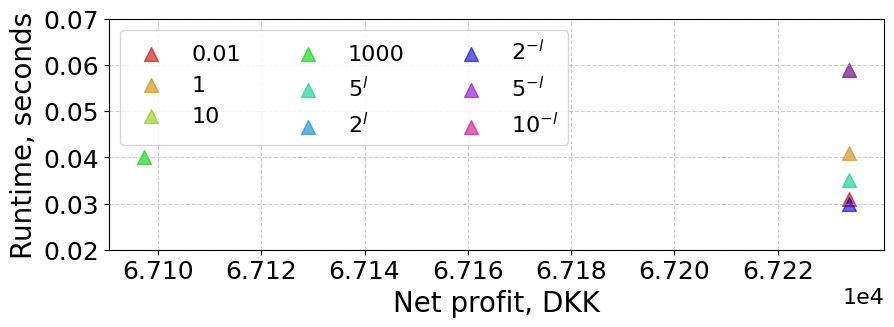

In [17]:
best_cases = []
for key, df in list(summary_tables.groupby(["methodology", "scenario_type", "case"]))[5: 6]:    
    plt.figure(figsize = (10, 3))
    i = 0
    for idx, row in df.iterrows():
        penalty = get_penalty_value(row["weights"])
        hyperparams = penalty 
        plt.scatter(row['objective_value'], row['runtime'], label=hyperparams, alpha=0.6, zorder=1, marker="^", s=100, color=colors[i])
        i = i + 1
    plt.legend(ncols=3, fontsize=16, loc="upper left")
    plt.xlabel("Net profit, DKK", fontsize=20)
    plt.ylabel("Runtime, seconds", fontsize=20)
    plt.xticks([(6.710 + 0.002 * i) * 10**4 for i in range(7)], fontsize=18)
    plt.yticks(fontsize=18)
    plt.ylim([0.02, 0.070])
    plt.grid(linestyle="--", zorder=0, alpha=0.6)
    plt.ticklabel_format(style='sci', axis='x', scilimits=(4, 4))
    plt.gca().xaxis.get_offset_text().set_fontsize(16)   
    plt.savefig(os.path.join(cwd, "images", "high_price_penalty_sensitivity.pdf"), bbox_inches="tight")    
    plt.show()

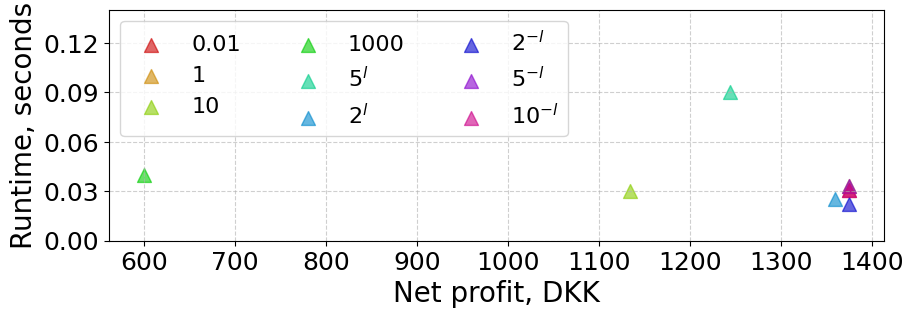

In [18]:
best_cases = []
for key, df in list(summary_tables.groupby(["methodology", "scenario_type", "case"]))[25: 26]:    
    plt.figure(figsize = (10, 3))
    i = 0
    for idx, row in df.iterrows():
        penalty = get_penalty_value(row["weights"])
        hyperparams = penalty 
        plt.scatter(row['objective_value'], row['runtime'], label=hyperparams, alpha=0.6, zorder=1, marker="^", s=100, color=colors[i])
        i = i + 1
    plt.legend(ncols=3, fontsize=16, loc="upper left")
    plt.xlabel("Net profit, DKK", fontsize=20)
    plt.ylabel("Runtime, seconds", fontsize=20)
    plt.xticks(fontsize=18)
    plt.yticks([0.00, 0.03, 0.06, 0.09, 0.12], fontsize=18)
    plt.ylim([0.00, 0.14])
    plt.grid(linestyle="--", zorder=0, alpha=0.6)
    plt.savefig(os.path.join(cwd, "images", "med_price_penalty_sensitivity.pdf"), bbox_inches="tight")
    plt.show()

('High_prices', 'PCAR')


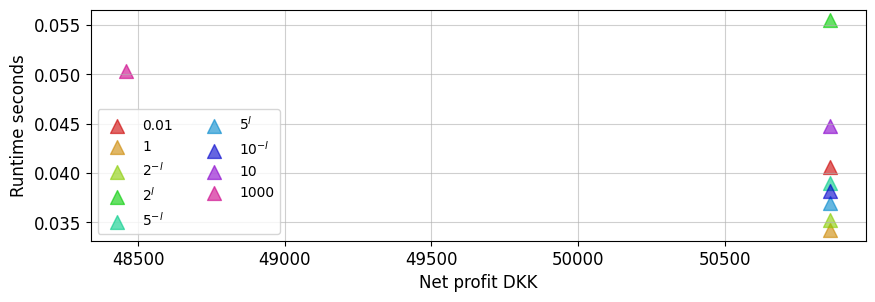

('High_prices', 'PCTAR')


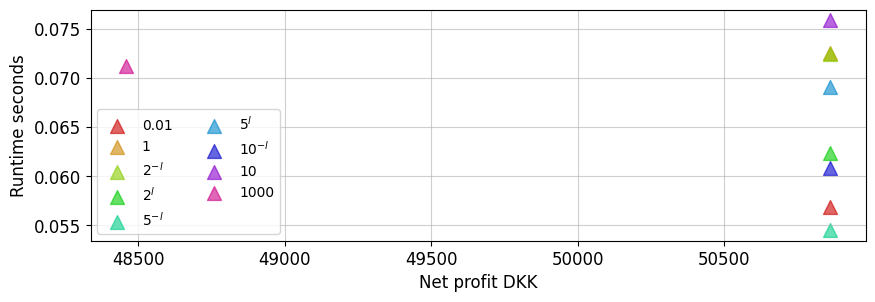

('Low_prices', 'PCAR')


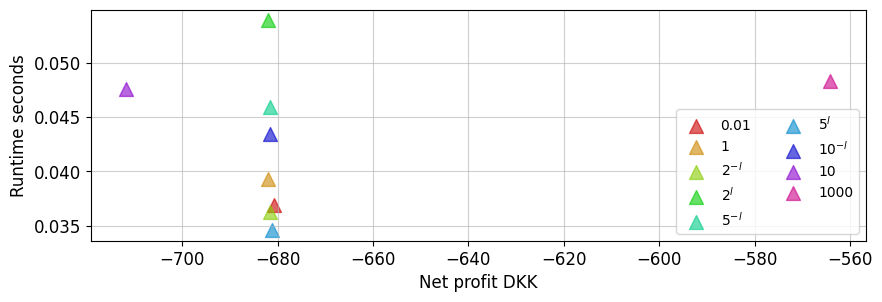

('Low_prices', 'PCTAR')


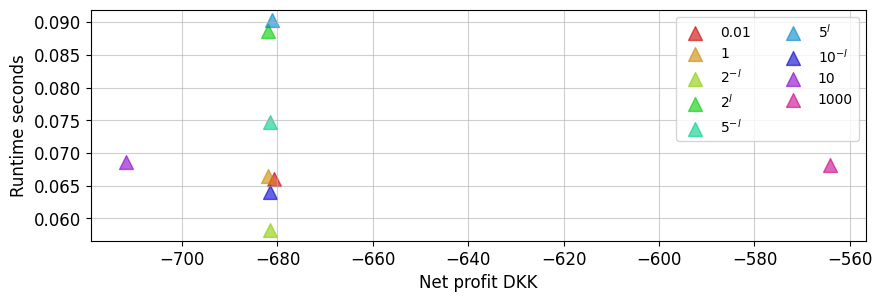

('Med_prices', 'PCAR')


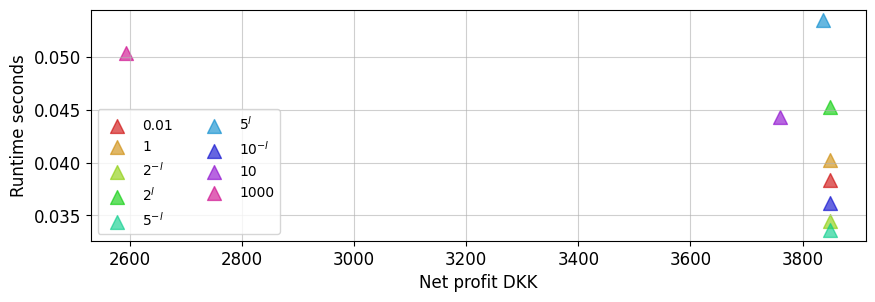

('Med_prices', 'PCTAR')


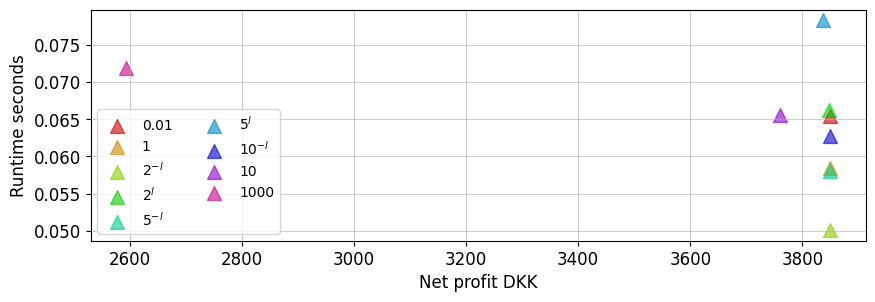

In [19]:
best_cases_dataframe = pd.DataFrame(columns=["scenario_type", "methodology", "objective_value", "runtime", "best weight"])
for key, df in list(summary_tables.groupby(["scenario_type", "methodology"])):
    print(key)
    plt.figure(figsize = (10, 3))
    i = 0
    grouped_df = df.groupby(["weights"])
    grouped_df = grouped_df[["objective_value", "runtime"]].mean().reset_index()
    grouped_df.runtime =  grouped_df.runtime.astype(float)
    best_case = identify_best_case(grouped_df)
    best_cases_dataframe.loc[len(best_cases_dataframe)] = [key[0], key[1], best_case.objective_value, best_case.runtime, best_case.weights]
    for idx, row in grouped_df.iterrows():
        penalty = get_penalty_value(row["weights"])
        hyperparams = penalty 
        plt.scatter(row['objective_value'], row['runtime'], label=hyperparams, alpha=0.6, zorder=1, marker="^", s=100, color=colors[i])
        i = i + 1
    plt.legend(ncols=2, fontsize="medium")
    plt.xlabel("Net profit DKK", fontsize="large")
    plt.ylabel("Runtime seconds", fontsize="large")
    plt.xticks(fontsize="large")
    plt.yticks(fontsize="large")
    # plt.ylim([0.02, 0.09])
    plt.grid(zorder=0, alpha=0.6)
    # plt.savefig(os.path.join(cwd, "images", "med_price_penalty_sensitivity.pdf"), bbox_inches="tight")
    plt.show()

In [20]:
df = best_cases_dataframe.groupby(["methodology", "scenario_type"])[["best weight"]].sum()

In [21]:
latex_code = df.to_latex()
print(latex_code)

\begin{tabular}{lll}
\toprule
 &  & best weight \\
methodology & scenario_type &  \\
\midrule
\multirow[t]{3}{*}{PCAR} & High_prices & (1, 0) \\
 & Low_prices & (1000, 0) \\
 & Med_prices & (5, -1) \\
\cline{1-3}
\multirow[t]{3}{*}{PCTAR} & High_prices & (5, -1) \\
 & Low_prices & (1000, 0) \\
 & Med_prices & (2, -1) \\
\cline{1-3}
\bottomrule
\end{tabular}

